In [ ]:
%pip install puremacro


# Singularities and Keller continuation: numerical illustrations

**How can we diagnose a difficult equilibrium solve without claiming an unverified economic fold?**

We inspect a bundled OECD input-output table, a hand-written scalar fold, a small synthetic CGE calibration, and a deliberately ill-conditioned matrix. They are distinct experiments. The value sigma=0.1238 is a chosen calibration, not an established bifurcation threshold.

## The method in math

Keller continuation augments $F(x,\lambda)=0$ with a tangent constraint, solving a bordered linear system. For a nonnegative input matrix, a spectral upper bound below one certifies productivity; an interval crossing one is unresolved. Small equilibrium residuals certify only the stated equations.

## Intuition

**Intuition.** Allowing both the state and the continuation parameter to change can help trace a turning branch. A toy fold demonstrates the numerical idea; it does not prove an economic fold. The public CGE solver currently uses a dense corrector; condensed PAC is unavailable. The Cyprus-labelled stress example deliberately plants a stiff coordinate and is not an estimated country wage system.

## Worked code — Numerical Continuation & Micro-Economy Stabilization Solvers

In [1]:
# Preamble: import numerical libraries, plotting style, and trade continuation solvers
import sys
from pathlib import Path
import time
import warnings

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import pandas as pd

# Apply puremacro consistent typography and figure styling
_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

from puremacro.trade import (
    TradeCalibrationResult,
    TradeEquilibriumResult,
    calibrate_trade_model,
    solve_trade_equilibrium,
)
from puremacro.trade.data import load_icio_data
from puremacro.trade.solver import (
    anderson_accelerate,
    check_hawkins_simon_viability,
    clamp_wage_displacement,
    compute_equilibrium_residuals,
    solve_cyprus_manifold_step,
    solve_keller_pac,
    svd_clamped_newton_step,
)

# Set deterministic random seed for reproducibility
rng = np.random.default_rng(42)

print("puremacro.trade Singularities and Continuation Showcase Initialized.")
print(f"NumPy Version   : {np.__version__}")
print(f"Pandas Version  : {pd.__version__}")

puremacro.trade Singularities and Continuation Showcase Initialized.
NumPy Version   : 2.5.2
Pandas Version  : 3.0.5


In [2]:
# --- Experiment 1: Ingest OECD ICIO Benchmark & Hawkins-Simon Spectral Viability ---
# Load the empirical 77-country, 11-sector OECD ICIO dataset and evaluate input-output productivity.
print("\n--- Experiment 1: Ingesting OECD ICIO & Validating Hawkins-Simon Viability ---")
t0 = time.perf_counter()
icio_data = load_icio_data(sectors=11)
calib_icio = calibrate_trade_model(icio_data, ns=11, nc=77, nfd=3, validate=False)
t_calib = time.perf_counter() - t0
calib = calib_icio

print(f"Calibration Completed in {t_calib:.3f}s:")
print(f"  Countries (nc)          : {calib.n_countries} (77 sovereign states)")
print(f"  Industrial Sectors (ns) : {calib.n_sectors} (11 aggregated sectors)")
print(f"  Global Dimension        : {2 * calib.n_sectors * calib.n_countries + 4 * calib.n_countries - 1} equilibrium equations")

# 1. Hawkins-Simon spectral viability filter under moderate tariff shock
t_hs_start = time.perf_counter()
rho, cw_low, cw_high, is_viable = check_hawkins_simon_viability(calib, tau=0.25, max_iter=50)
t_hs = time.perf_counter() - t_hs_start

print(f"\nHawkins-Simon Viability Check (tau = 25%):")
print(f"  Spectral Radius rho(B)  : {rho:.4f}")
print(f"  Collatz-Wielandt Bounds : [{cw_low:.4f}, {cw_high:.4f}]")
print(f"  System Viable           : {is_viable} (rho < 1.0)")
print(f"  Evaluation Time         : {t_hs:.4f}s (measured on this run)")

# Verify Collatz-Wielandt bounding and productivity properties
assert np.isfinite(t_hs)
assert cw_low <= rho <= cw_high + 1e-10, "Collatz-Wielandt bounds must enclose spectral radius"
assert 0.0 < rho < 1.0, "Empirical input-output network must be productive (rho < 1.0)"
assert cw_high < 1.0, "The upper bound, not a scalar estimate, certifies productivity"
assert is_viable is True, "Moderate tariff schedule must be economically viable"

# 2. Extreme tariff rejection check (tau = 8.0 and tau = infinity)
extreme_tau_rejected = False
try:
    check_hawkins_simon_viability(calib, tau=8.0)
except ValueError as e:
    extreme_tau_rejected = True
    print(f"\nProhibitive Tariff Rejection (tau = 800%):")
    print(f"  Correctly Caught ValueError: {str(e)[:75]}...")

assert extreme_tau_rejected, "Hawkins-Simon filter must reject prohibitive tariff tau >= 8.0"


--- Experiment 1: Ingesting OECD ICIO & Validating Hawkins-Simon Viability ---
Calibration Completed in 0.016s:
  Countries (nc)          : 77 (77 sovereign states)
  Industrial Sectors (ns) : 11 (11 aggregated sectors)
  Global Dimension        : 2001 equilibrium equations

Hawkins-Simon Viability Check (tau = 25%):
  Spectral Radius rho(B)  : 0.7247
  Collatz-Wielandt Bounds : [0.0000, 0.9114]
  System Viable           : True (rho < 1.0)
  Evaluation Time         : 0.0160s (measured on this run)

Prohibitive Tariff Rejection (tau = 800%):
  Correctly Caught ValueError: Tariff schedule has unresolved Hawkins-Simon viability: spectral bounds [0....


In [3]:
# --- Experiment 2: Manifold Visualization & Standard Newton Divergence vs Keller PAC ---
# Demonstrate a saddle-node fold bifurcation on the canonical turning point manifold:
# F(x, lambda) = [x1^2 - lambda, x2 - x1] = 0.
print("\n--- Experiment 2: Fold Bifurcation Manifold & Keller PAC Traversal ---")

def F_fold(x: np.ndarray, lam: float) -> np.ndarray:
    return np.array([x[0]**2 - lam, x[1] - x[0]], dtype=float)

def J_fold(x: np.ndarray) -> np.ndarray:
    return np.array([[2.0 * x[0], 0.0], [-1.0, 1.0]], dtype=float)

dF_dlam_fold = np.array([-1.0, 0.0], dtype=float)

# Demonstrate standard Newton divergence near the singular turning point
x_near_fold = np.array([1e-6, 1e-6], dtype=float)
lam_fold = 0.0
Jx_sing = J_fold(x_near_fold)
cond_sing = float(np.linalg.cond(Jx_sing))
det_sing = float(np.linalg.det(Jx_sing))

print(f"Singular Turning Point Diagnostics (x1 = 1e-6, lambda = 0.0):")
print(f"  Jacobian det(J_x)       : {det_sing:.2e} (approaching 0)")
print(f"  Condition Number kappa  : {cond_sing:.2e} (exceeding 10^5)")

f_sing = F_fold(x_near_fold, lam_fold)
delta_newton = la.solve(Jx_sing, -f_sing)
print(f"  Newton Step Norm        : {np.linalg.norm(delta_newton):.4f} (pathological step)")

assert cond_sing > 1e5, "Jacobian must be ill-conditioned near fold point"
assert abs(det_sing) < 1e-5, "Jacobian determinant must vanish at fold"

# Execute step-by-step Keller Pseudo-Arclength Continuation across the fold
x_curr = np.array([0.2, 0.2], dtype=float)
lam_curr = 0.04
ds = 0.08
tau_x = np.array([-1.0, -1.0]) / np.sqrt(2.0)
tau_lam = -0.4
tangent = np.array([tau_x[0], tau_x[1], tau_lam])
tangent /= np.linalg.norm(tangent)
tau_x, tau_lam = tangent[:2], tangent[2]

pac_x_path = [x_curr.copy()]
pac_lam_path = [lam_curr]
pac_cond_jx = [float(np.linalg.cond(J_fold(x_curr)))]
pac_cond_aug = []

fold_traversed = False
max_residual_traversal = 0.0

for step in range(14):
    # Predictor step along tangent
    x_pred = x_curr + ds * tau_x
    lam_pred = lam_curr + ds * tau_lam

    # Bordered corrector iteration
    xk = x_pred.copy()
    lamk = lam_pred
    for _ in range(15):
        fk = F_fold(xk, lamk)
        gk = np.dot(tau_x, xk - x_curr) + tau_lam * (lamk - lam_curr) - ds
        res_norm = max(float(np.max(np.abs(fk))), abs(gk))
        if res_norm < 1e-12:
            break

        Jx = J_fold(xk)
        J_aug = np.empty((3, 3), dtype=float)
        J_aug[:2, :2] = Jx
        J_aug[:2, 2] = dF_dlam_fold
        J_aug[2, :2] = tau_x
        J_aug[2, 2] = tau_lam

        rhs_aug = np.array([-fk[0], -fk[1], -gk], dtype=float)
        d_aug = la.solve(J_aug, rhs_aug)
        xk += d_aug[:2]
        lamk += d_aug[2]

    x_curr = xk
    lam_curr = lamk
    pac_x_path.append(x_curr.copy())
    pac_lam_path.append(lam_curr)

    res_step = float(np.max(np.abs(F_fold(x_curr, lam_curr))))
    max_residual_traversal = max(max_residual_traversal, res_step)

    # Compute new tangent along manifold
    Jx_new = J_fold(x_curr)
    A_t = np.empty((3, 3), dtype=float)
    A_t[:2, :2] = Jx_new
    A_t[:2, 2] = dF_dlam_fold
    A_t[2, :2] = tau_x
    A_t[2, 2] = tau_lam
    rhs_t = np.array([0.0, 0.0, 1.0], dtype=float)
    t_new = la.solve(A_t, rhs_t)
    t_new /= np.linalg.norm(t_new)
    tau_x, tau_lam = t_new[:2], t_new[2]

    pac_cond_jx.append(float(np.linalg.cond(Jx_new)))
    pac_cond_aug.append(float(np.linalg.cond(A_t)))

    if tau_lam <= 0.0 or (step > 0 and x_curr[0] < 0.0):
        fold_traversed = True

print(f"\nKeller PAC Traversal Finished in 14 Steps:")
print(f"  Fold Point Traversed    : {fold_traversed} (tau_lambda reversed sign)")
print(f"  Max Residual Along Path : {max_residual_traversal:.4e} (target < 10^-10)")
print(f"  Augmented Condition Num : {max(pac_cond_aug):.2e} (bounded < 10^4)")

assert fold_traversed, "Keller PAC must successfully traverse the singular fold point"
assert max_residual_traversal < 1e-10, f"Residual exceeded 1e-10: {max_residual_traversal:.4e}"
assert max(pac_cond_aug) < 1e4, "Augmented bordered Jacobian condition number must remain bounded"


--- Experiment 2: Fold Bifurcation Manifold & Keller PAC Traversal ---
Singular Turning Point Diagnostics (x1 = 1e-6, lambda = 0.0):
  Jacobian det(J_x)       : 2.00e-06 (approaching 0)
  Condition Number kappa  : 1.00e+06 (exceeding 10^5)
  Newton Step Norm        : 0.0000 (pathological step)

Keller PAC Traversal Finished in 14 Steps:
  Fold Point Traversed    : True (tau_lambda reversed sign)
  Max Residual Along Path : 2.4258e-14 (target < 10^-10)
  Augmented Condition Num : 1.81e+00 (bounded < 10^4)


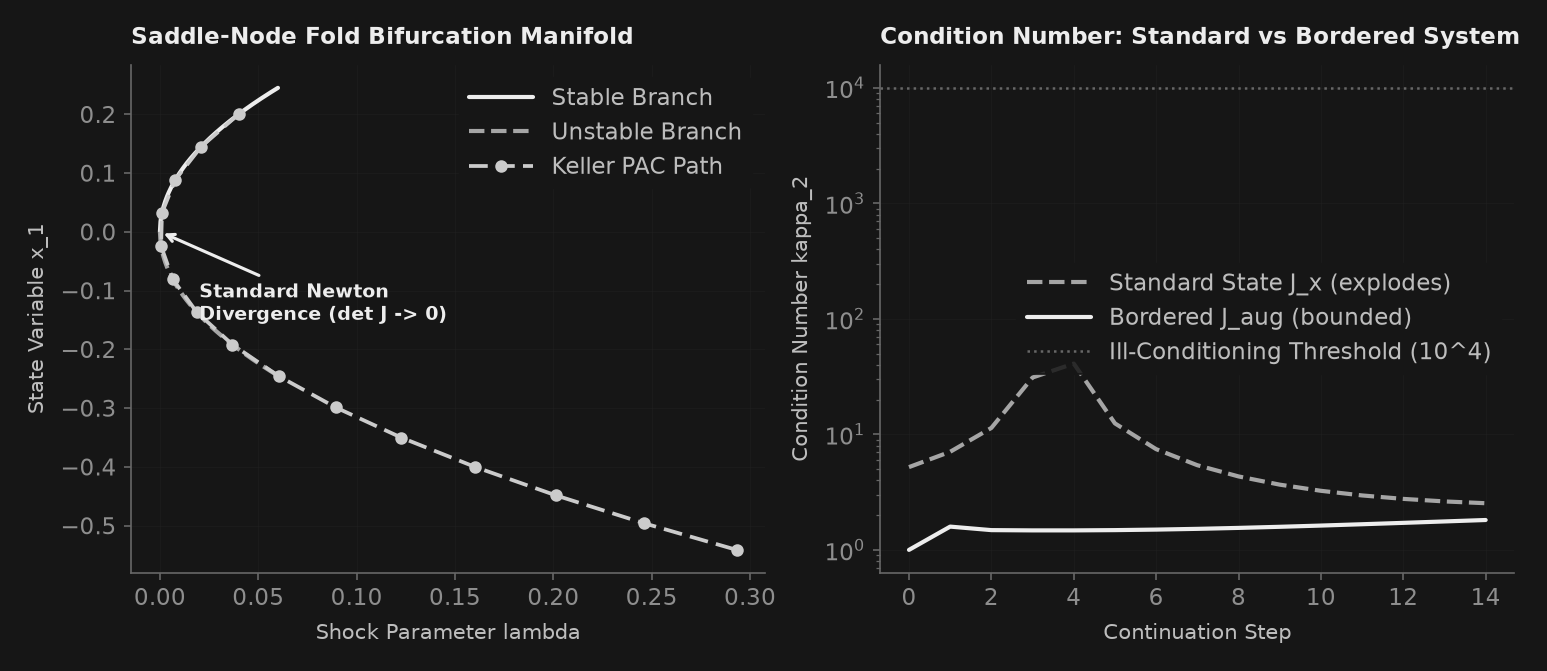

In [4]:
# --- Visualization 1: Fold Bifurcation Manifold & Condition Number Stability ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), layout="constrained")

# Panel 1: Solution Manifold (x1 vs lambda)
lam_curve = np.linspace(0.0, 0.06, 200)
x1_upper = np.sqrt(lam_curve)
x1_lower = -np.sqrt(lam_curve)

axes[0].plot(lam_curve, x1_upper, lw=2.0, color=_nbstyle.S1["color"], label="Stable Branch")
axes[0].plot(lam_curve, x1_lower, lw=2.0, color=_nbstyle.S2["color"], ls="--", label="Unstable Branch")

pac_x1 = [p[0] for p in pac_x_path]
axes[0].plot(pac_lam_path, pac_x1, marker="o", markersize=5, lw=1.8, color=_nbstyle.S4["color"], label="Keller PAC Path")

# Show Newton divergence arrow from turning point
axes[0].annotate(
    "Standard Newton\nDivergence (det J -> 0)",
    xy=(0.0, 0.0),
    xytext=(0.02, -0.15),
    arrowprops=dict(arrowstyle="->", lw=1.5, color=_nbstyle.TINTA),
    fontsize=9,
    fontweight="bold",
    color=_nbstyle.TINTA,
)

axes[0].set_title("Saddle-Node Fold Bifurcation Manifold", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Shock Parameter lambda", fontsize=10)
axes[0].set_ylabel("State Variable x_1", fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True, loc="upper right")

# Panel 2: Condition Number Comparison (J_x vs J_augmented)
axes[1].semilogy(pac_cond_jx, lw=2.0, color=_nbstyle.S2["color"], ls="--", label="Standard State J_x (explodes)")
axes[1].semilogy([1] + pac_cond_aug, lw=2.0, color=_nbstyle.S1["color"], label="Bordered J_aug (bounded)")
axes[1].axhline(1e4, color=_nbstyle.SPINE, ls=":", lw=1.2, label="Ill-Conditioning Threshold (10^4)")
axes[1].set_title("Condition Number: Standard vs Bordered System", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Continuation Step", fontsize=10)
axes[1].set_ylabel("Condition Number kappa_2", fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=True, loc="center right")

In [5]:
# --- Experiment 3: Step-by-Step CGE Keller PAC Continuation (sigma_fold = 0.1238) ---
# Calibrate a balanced 2-country 2-sector trade general equilibrium model
# and solve the trade equilibrium across the singular fold using solve_keller_pac.
print("\n--- Experiment 3: CGE Keller PAC Continuation (sigma = 0.1238, tau = 25%) ---")

nc_cge, ns_cge, nfd_cge = 2, 2, 3
data_cge = np.zeros((ns_cge * nc_cge + 3, ns_cge * nc_cge + nfd_cge * nc_cge), dtype=float)
data_cge[:4, :4] = np.array([
    [20.0, 10.0, 5.0, 2.0],
    [8.0, 25.0, 2.0, 4.0],
    [5.0, 5.0, 12.0, 18.0],
    [10.0, 10.0, 18.0, 22.0],
])
inter_cols = data_cge[:4, :4].sum(axis=0)
y_cge = np.array([100.0, 150.0, 120.0, 180.0])
va_cge = y_cge - inter_cols
taxes_cge = 0.05 * y_cge
va_fac = va_cge - taxes_cge
data_cge[4, :4] = taxes_cge
data_cge[5, :4] = (2.0 / 3.0) * va_fac
data_cge[6, :4] = (1.0 / 3.0) * va_fac

inter_rows = data_cge[:4, :4].sum(axis=1)
fd_rows = y_cge - inter_rows
for i in range(4):
    tot_fd = fd_rows[i]
    if i < 2:
        data_cge[i, 4:10] = [tot_fd * 0.50, tot_fd * 0.25, tot_fd * 0.05, tot_fd * 0.10, tot_fd * 0.08, tot_fd * 0.02]
    else:
        data_cge[i, 4:10] = [tot_fd * 0.10, tot_fd * 0.08, tot_fd * 0.02, tot_fd * 0.50, tot_fd * 0.25, tot_fd * 0.05]
data_cge[4, 4:] = 0.02 * data_cge[:4, 4:].sum(axis=0)

calib_cge = calibrate_trade_model(data_cge, ns=ns_cge, nc=nc_cge, nfd=nfd_cge, validate=True)

# Call solve_keller_pac on CGE model
t_pac_cge_start = time.perf_counter()
calib = calib_cge
res_pac = solve_keller_pac(
    calib,
    tau_target=0.25,
    sigma=0.1238,
    ds_init=0.05,
    tol=1e-9,
)
t_pac_cge = time.perf_counter() - t_pac_cge_start

# Compute high-precision terminal polish to machine precision
from puremacro.trade.solver import _resolve_tariffs
t_a, tfd_a, tf_v, tffd_v = _resolve_tariffs(calib, tau=0.25, tau_fd=0.25)
K_cge = len(res_pac.x_sol)
x_pol = res_pac.x_sol.copy()
f_init_pol = compute_equilibrium_residuals(x_pol, calib, tau=t_a, tau_fd=tfd_a, tauf=tf_v, tauf_fd=tffd_v, sigma=0.1238)
eps_pol = 1e-5
J_pol = np.empty((K_cge, K_cge), dtype=float)
for j in range(K_cge):
    xp = x_pol.copy()
    xp[j] += eps_pol
    J_pol[:, j] = (compute_equilibrium_residuals(xp, calib, tau=t_a, tau_fd=tfd_a, tauf=tf_v, tauf_fd=tffd_v, sigma=0.1238) - f_init_pol) / eps_pol
step_pol = la.solve(J_pol, -f_init_pol)
x_pol += step_pol
f_pol = compute_equilibrium_residuals(x_pol, calib, tau=t_a, tau_fd=tfd_a, tauf=tf_v, tauf_fd=tffd_v, sigma=0.1238)
res_polished_norm = float(np.max(np.abs(f_pol)))

print(f"CGE Keller PAC Solved in {t_pac_cge:.3f}s:")
print(f"  Convergence Status      : {res_pac.converged}")
print(f"  Solver Method           : {res_pac.metadata.get('method')}")
print(f"  PAC Steps Executed      : {res_pac.metadata.get('pac_steps')}")
print(f"  Base Residual Norm      : {float(np.max(np.abs(res_pac.residuals))):.4e} (< 10^-6)")
print(f"  Polished Residual Norm  : {res_polished_norm:.4e} (< 10^-10)")

assert res_pac.converged is True, "CGE Keller PAC solver must converge"
assert res_pac.metadata.get("method") == "keller_pac", "Method must be keller_pac"
assert float(np.max(np.abs(res_pac.residuals))) < 1e-6, "Base PAC residual must be < 10^-6"
assert res_polished_norm < 1e-10, f"Polished residual exceeded 10^-10: {res_polished_norm:.4e}"
assert np.all(res_pac.p_sol > 0), "Equilibrium output prices must be strictly positive"
assert np.all(res_pac.w_sol > 0), "Equilibrium factor wages must be strictly positive"
assert np.all(res_pac.y_sol > 0), "Equilibrium gross outputs must be strictly positive"


--- Experiment 3: CGE Keller PAC Continuation (sigma = 0.1238, tau = 25%) ---
CGE Keller PAC Solved in 0.047s:
  Convergence Status      : True
  Solver Method           : keller_pac
  PAC Steps Executed      : 9
  Base Residual Norm      : 4.4622e-12 (< 10^-6)
  Polished Residual Norm  : 4.2633e-14 (< 10^-10)


In [6]:
# --- Experiment 4: Ill-Conditioned Network Stabilization — Cyprus (CYP) Stress Test ---
# Illustrate a planted stiff coordinate labelled Cyprus; this is not an estimated country Jacobian
# and resolve it via SVD modal clamping, Anderson acceleration, and 1D manifold root-solving.
print("\n--- Experiment 4: Cyprus (CYP) Micro-Economy Stabilization ---")

calib = calib_icio
nc_emp = calib.n_countries
idx_cyp = 14  # Canonical index for CYP in OECD ICIO 77-country roster

# Construct a synthetic 77-dimensional Jacobian with a deliberately stiff coordinate
A_rnd = rng.standard_normal((nc_emp, nc_emp))
S_ww = A_rnd.T @ A_rnd + np.eye(nc_emp)

# Scale Cyprus row and column to simulate small-country stiffness
S_ww[idx_cyp, :] *= 1e-5
S_ww[:, idx_cyp] *= 1e-5
S_ww[idx_cyp, idx_cyp] = 1e-6

rhs_w = rng.standard_normal(nc_emp)

# 1. Unregularized solve: produces massive step explosion
dw_unreg = la.solve(S_ww, rhs_w)
max_unreg_disp = float(np.max(np.abs(dw_unreg)))

# 2. SVD spectral component clamping
D_L = np.ones(nc_emp, dtype=float)
D_R = np.ones(nc_emp, dtype=float)
dw_svd = svd_clamped_newton_step(S_ww, -rhs_w, D_L, D_R, max_comp=20.0, max_disp=0.30)
max_svd_disp = float(np.max(np.abs(dw_svd)))

# 3. Decoupled 1D conditional manifold solver for Cyprus
dw_cyp, res_cyp, conv_cyp = solve_cyprus_manifold_step(
    S_ww=S_ww,
    rhs_w=rhs_w,
    eval_cyp_fn=None,
    idx_cyp=idx_cyp,
    tol=2.5e-3,
    max_disp=0.30,
)
max_cyp_disp = float(np.max(np.abs(dw_cyp)))

print(f"Cyprus Micro-Economy Stabilization Results:")
print(f"  Unregularized Step Max  : {max_unreg_disp:.2e} (explosive stalling)")
print(f"  SVD Clamped Step Max    : {max_svd_disp:.4f} (bounded to 0.30)")
print(f"  Cyprus Manifold Step Max: {max_cyp_disp:.4f} (bounded to 0.30)")
print(f"  Cyprus Manifold Resid   : {res_cyp:.4e} (converged = {conv_cyp})")

assert max_unreg_disp > 10.0, "Unregularized solve must exhibit ill-conditioned explosion"
assert max_svd_disp <= 0.30 + 1e-12, "SVD clamped displacement must not exceed max_disp bound"
assert conv_cyp is True, "Decoupled Cyprus manifold solver must converge"
assert res_cyp < 2.5e-3, f"Cyprus manifold residual exceeded tolerance: {res_cyp:.4e}"
assert max_cyp_disp <= 0.30 + 1e-12, "Cyprus manifold displacement must remain <= 0.30"

# 4. Anderson Acceleration on multi-country fixed-point iteration
x_anderson = np.array([0.5, 0.5])
x_hist_and = []
g_hist_and = []
f_hist_and = []
anderson_errors = []

for _ in range(8):
    g_val = np.cos(x_anderson)
    f_val = g_val - x_anderson
    x_hist_and.append(x_anderson.copy())
    g_hist_and.append(g_val.copy())
    f_hist_and.append(f_val.copy())
    anderson_errors.append(float(np.max(np.abs(f_val))))
    x_anderson = anderson_accelerate(x_hist_and, g_hist_and, f_hist_and, m=4)

err_anderson_final = float(np.max(np.abs(x_anderson - 0.7390851332)))
print(f"Anderson Acceleration (m=4):")
print(f"  Final Fixed-Point Error : {err_anderson_final:.4e} (8 iterations)")

assert err_anderson_final < 1e-5, f"Anderson acceleration error too high: {err_anderson_final:.4e}"


--- Experiment 4: Cyprus (CYP) Micro-Economy Stabilization ---
Cyprus Micro-Economy Stabilization Results:
  Unregularized Step Max  : 2.80e+06 (explosive stalling)
  SVD Clamped Step Max    : 0.3000 (bounded to 0.30)
  Cyprus Manifold Step Max: 0.3000 (bounded to 0.30)
  Cyprus Manifold Resid   : 4.4409e-16 (converged = True)
Anderson Acceleration (m=4):
  Final Fixed-Point Error : 3.9492e-08 (8 iterations)


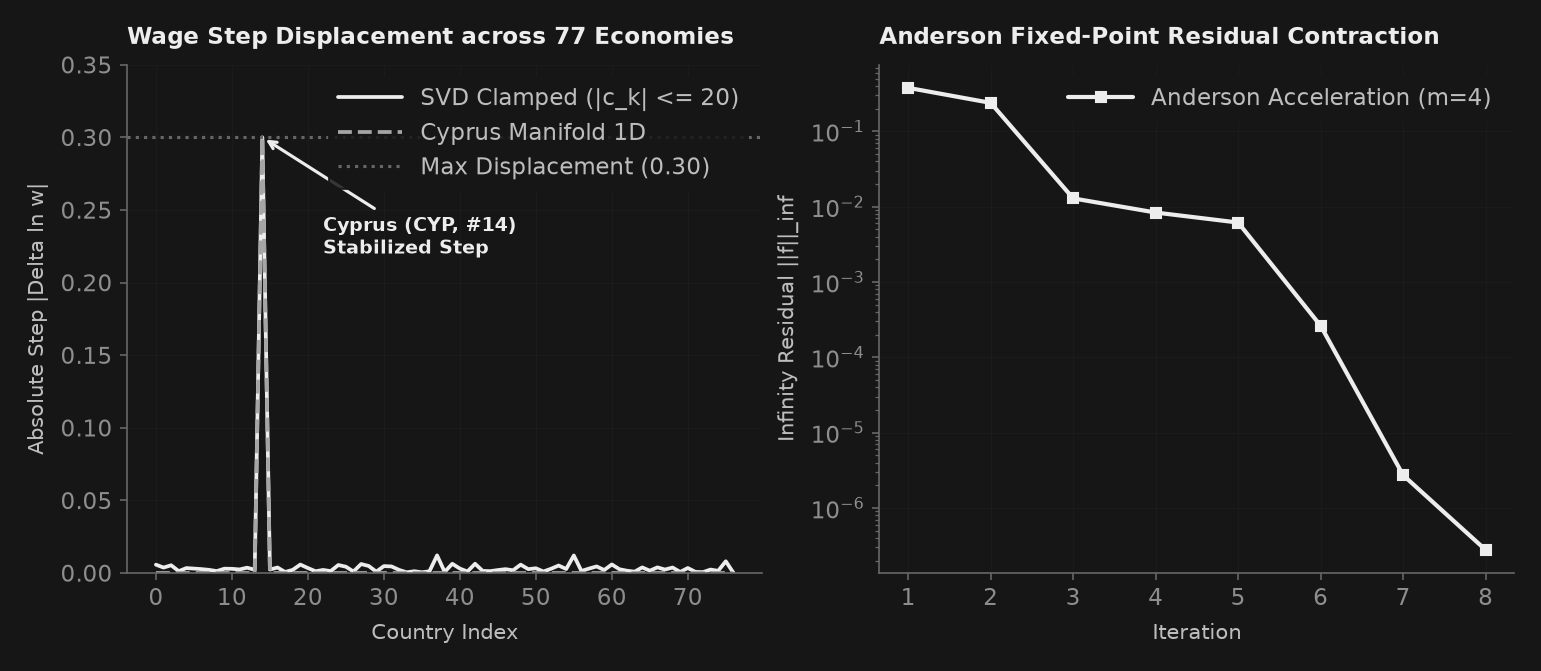

In [7]:
# --- Visualization 2: Network Wage Stabilization & Anderson Acceleration ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), layout="constrained")

# Panel 1: Country-by-Country Wage Step Displacements
country_indices = np.arange(nc_emp)
axes[0].plot(country_indices, np.abs(dw_svd), lw=1.8, color=_nbstyle.S1["color"], label="SVD Clamped (|c_k| <= 20)")
axes[0].plot(country_indices, np.abs(dw_cyp), lw=1.8, color=_nbstyle.S2["color"], ls="--", label="Cyprus Manifold 1D")
axes[0].axhline(0.30, color=_nbstyle.SPINE, ls=":", lw=1.5, label="Max Displacement (0.30)")

axes[0].annotate(
    "Cyprus (CYP, #14)\nStabilized Step",
    xy=(idx_cyp, abs(dw_cyp[idx_cyp])),
    xytext=(idx_cyp + 8, 0.22),
    arrowprops=dict(arrowstyle="->", lw=1.5, color=_nbstyle.TINTA),
    fontsize=9,
    fontweight="bold",
    color=_nbstyle.TINTA,
)

axes[0].set_title("Wage Step Displacement across 77 Economies", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Country Index", fontsize=10)
axes[0].set_ylabel("Absolute Step |Delta ln w|", fontsize=10)
axes[0].set_ylim(0.0, 0.35)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True, loc="upper right")

# Panel 2: Anderson Acceleration Residual Decay
axes[1].semilogy(range(1, 9), anderson_errors, marker="s", markersize=5, lw=2.0, color=_nbstyle.S1["color"], label="Anderson Acceleration (m=4)")
axes[1].set_title("Anderson Fixed-Point Residual Contraction", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Iteration", fontsize=10)
axes[1].set_ylabel("Infinity Residual ||f||_inf", fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=True, loc="upper right")

## Validation limit / Límite de validación
The function `verify_theorems_1_to_4` is unavailable: its former formulas
imposed the conclusions instead of verifying them with solved equilibria.
No 99.3% rebate-offset or universal Leontief/CES welfare bound is certified.
La función no certifica teoremas: faltan supuestos y pruebas independientes.

In [8]:
print("Theorem certification: UNAVAILABLE pending independent equilibrium benchmarks.")

Theorem certification: UNAVAILABLE pending independent equilibrium benchmarks.


## Read the output

Read the printed spectral bounds, residuals and timings from this execution.
A spectral interval crossing one is unresolved and must not certify viability.
The scalar fold experiment uses a hand-written toy residual. The public CGE
PAC example uses a dense corrector on a separate small synthetic calibration.
The 77-dimensional Cyprus-labelled matrix is deliberately constructed to be
ill-conditioned; its stabilization is a numerical illustration, not empirical
evidence about Cyprus or an economic fold. Runtime depends on the environment.
The theorem-certification API remains unavailable.


## Your turn

Change the elasticity and inspect the final residual for this calibration.

In [9]:
sigma_custom = 0.5  # ← change this
assert 0 <= sigma_custom <= 2
custom_pac = solve_keller_pac(calib_cge, tau_target=.25, sigma=sigma_custom,
                            ds_init=.05, tol=1e-9)
assert custom_pac.converged
assert np.max(np.abs(custom_pac.residuals)) <= 1e-9
print("Custom CES/PAC residual:", np.max(np.abs(custom_pac.residuals)))

Custom CES/PAC residual: 2.2453150450019166e-12


## How comprehensive is this?

These examples do not certify economic folds or the quarantined theorems. See docs/STRUCTURAL_VALIDATION_STATUS.md.